In [3]:
import cv2
import pytesseract
import numpy as np
import tqdm
import pandas as pd
from matplotlib import pyplot as plt
import pprint

%load_ext autoreload
%autoreload 2

In [68]:
from matchinator import pass1, pass2, util, consts, matchers

In [10]:
cap = cv2.VideoCapture("/home/guinea/remote/cmptx_ochoa_d1_1.ts")

In [12]:
def seek(cap: cv2.VideoCapture, minutes: float, seconds: float):
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    frame = None
    print(f"Target is {(minutes * 60 + seconds) * fps}, fps is {fps}")
    cap.set(cv2.CAP_PROP_POS_FRAMES, (minutes * 60 + seconds) * fps)
    #for i in range(int((minutes * 60 + seconds) * fps)):
    #    print(i, cap.get(cv2.CAP_PROP_POS_MSEC))
    #    succ, new_frame = cap.read()
    #    if succ:
    #        frame = new_frame
    #        continue

    #print(f"Succeeded at {i}")
    #return frame 

Target is 97560, fps is 30


[NULL @ 0x5831e3939940] chroma_log2_weight_denom 11 is out of range
[NULL @ 0x5831e3939940] illegal reordering_of_pic_nums_idc 15
[NULL @ 0x5831e3939940] luma_log2_weight_denom 32 is out of range
[NULL @ 0x5831e3939940] illegal reordering_of_pic_nums_idc 7
[NULL @ 0x5831e3939940] illegal reordering_of_pic_nums_idc 7
[NULL @ 0x5831e3939940] illegal reordering_of_pic_nums_idc 7
[h264 @ 0x5831dfd0f8c0] reference count overflow
[h264 @ 0x5831dfd0f8c0] decode_slice_header error
[h264 @ 0x5831dfd0f8c0] no frame!
[h264 @ 0x5831e00f1900] illegal modification_of_pic_nums_idc 7
[h264 @ 0x5831e00f1900] decode_slice_header error
[h264 @ 0x5831e00f1900] no frame!
[h264 @ 0x5831e17af500] reference overflow 2 > 15 or 38 > 15
[h264 @ 0x5831e17af500] decode_slice_header error
[h264 @ 0x5831e17af500] no frame!
[NULL @ 0x5831e3939940] reference overflow 261 > 15 or 0 > 15
[h264 @ 0x5831e01a2bc0] reference overflow 0 > 15 or 158 > 15
[h264 @ 0x5831e01a2bc0] decode_slice_header error
[h264 @ 0x5831e01a2bc0

True


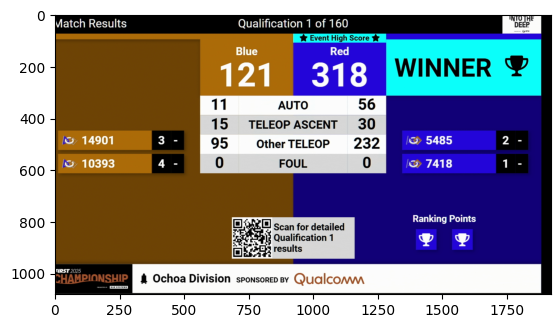

In [13]:
#seek(cap, 47, 32)
seek(cap, 54, 12)
succ, frame = cap.read()
print(succ)
plt.imshow(frame)

In [19]:
match_result.detect_match_result(cap.get(cv2.CAP_PROP_POS_MSEC) / 100, frame, params)

MatchResultScreen(ftc_events_url='https://ftc.events/FTCCMP1OCHO/qualifications/1', start_ts=32519.990000000005, end_ts=32520.990000000005)

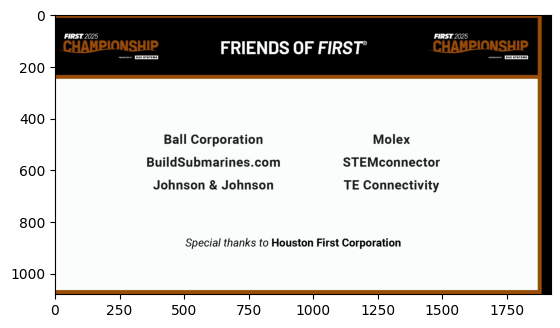

In [17]:
plt.imshow(frame)

In [61]:
(47 * 60 + 30) * 1000

2850000

In [84]:
cap.set(cv2.CAP_PROP_POS_FRAMES, 85500)

[NULL @ 0x5a5f9cd6d900] chroma_log2_weight_denom 11 is out of range
[NULL @ 0x5a5f9cd6d900] illegal reordering_of_pic_nums_idc 15
[NULL @ 0x5a5f9cd6d900] luma_log2_weight_denom 32 is out of range
[NULL @ 0x5a5f9cd6d900] chroma_log2_weight_denom 17 is out of range
[NULL @ 0x5a5f9cd6d900] illegal memory management control operation 30
[h264 @ 0x5a5fa3646980] Missing reference picture, default is 0
[h264 @ 0x5a5fa3646980] decode_slice_header error
[h264 @ 0x5a5f9a6cd500] illegal modification_of_pic_nums_idc 31
[h264 @ 0x5a5f9a6cd500] decode_slice_header error
[h264 @ 0x5a5f9a6cd500] no frame!
[NULL @ 0x5a5f9cd6d900] reference count 2 overflow
[h264 @ 0x5a5f9706ca00] reference overflow 16 > 15 or 11 > 15
[h264 @ 0x5a5f9706ca00] decode_slice_header error
[h264 @ 0x5a5f9706ca00] no frame!
[h264 @ 0x5a5fa35e62c0] reference count overflow
[h264 @ 0x5a5fa35e62c0] decode_slice_header error
[h264 @ 0x5a5fa35e62c0] no frame!
[h264 @ 0x5a5fa078cac0] reference overflow 1 > 15 or 34 > 15
[h264 @ 0x5a

True

True

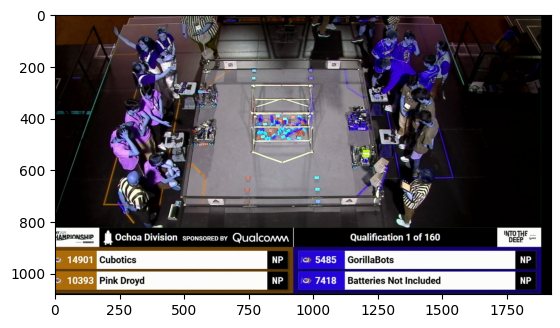

In [85]:
succ, frame = cap.read()
plt.imshow(frame)
succ

In [79]:
match_frame = frame

In [16]:
params = consts.ScaledParams(1920, 1080)

In [43]:
logo_matcher = matchers.ITDLogoMatcher(params)
basket_matcher = matchers.ITDRedBasketMatcher(params)

In [15]:
has_logo, match_tlbr = logo_matcher.match(frame)
match_tlbr

((1708, 825), (1878, 899))

In [50]:
match_display, match_is_top = util.get_match_display(frame, match_tlbr, params)
match_is_top

False

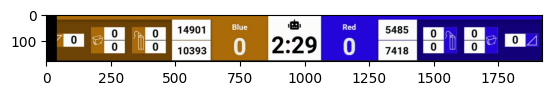

In [51]:
plt.imshow(match_display)

In [52]:
util.match_is_preview(match_display, basket_matcher, params)

False

In [59]:
timestamp, other = util.extract_match_time(match_display, params)
timestamp

'2:29'

In [61]:
util.are_colors_flipped(match_display, params)

False

In [62]:
cap.get(cv2.CAP_PROP_POS_MSEC) / 1000

3003.9990000000003

In [66]:
match_name, _ = util.extract_match_name(frame, match_tlbr, params)
match_name

'Qualification 1 of 160'

In [67]:
display_data = util.extract_display_data(match_display, params)
display_data

DisplayData(display_flipped=False, red_teams=('5485', '7418'), blue_teams=('14901', '10393'))

In [71]:
results = pass1.run("/home/guinea/remote/cmptx_ochoa_d1_1.ts", seek=85200)

[NULL @ 0x5897261c4d80] chroma_log2_weight_denom 11 is out of range
[NULL @ 0x5897261c4d80] illegal reordering_of_pic_nums_idc 15
[NULL @ 0x5897261c4d80] luma_log2_weight_denom 32 is out of range
[NULL @ 0x5897261c4d80] chroma_log2_weight_denom 16 is out of range
[h264 @ 0x58972c0aa480] reference count overflow
[h264 @ 0x58972c0aa480] decode_slice_header error
[h264 @ 0x58972c0aa480] no frame!
[h264 @ 0x58972dc95900] deblocking filter parameters 0 -9 out of range
[h264 @ 0x58972dc95900] decode_slice_header error
[h264 @ 0x58972dc95900] no frame!
[h264 @ 0x58972dca8d40] reference count overflow
[h264 @ 0x58972dca8d40] decode_slice_header error
[h264 @ 0x58972dca8d40] no frame!
[NULL @ 0x5897261c4d80] reference count 2 overflow
[h264 @ 0x58972dca5780] reference overflow 16 > 15 or 9 > 15
[h264 @ 0x58972dca5780] decode_slice_header error
[h264 @ 0x58972dca5780] no frame!
[h264 @ 0x58972dd94bc0] reference count overflow
[h264 @ 0x58972dd94bc0] decode_slice_header error
[h264 @ 0x58972dd94b

In [74]:
pprint.pprint(results)

Pass1EventData(fps=30,
               width=1920,
               height=1080,
               matches=[Pass1EventMatch(name='Qualification 1 of 160',
                                        top=False,
                                        frame_idx=89430,
                                        video_sec=3003.565,
                                        match_ts=149,
                                        display_data=DisplayData(display_flipped=False,
                                                                 red_teams=('5485',
                                                                            '7418'),
                                                                 blue_teams=('14901',
                                                                             '10393')),
                                        is_replay=False),
                        Pass1EventMatch(name='Qualification 1 of 160',
                                        top=False,
                  

In [187]:
p2 = pass2.combine_matches(results, seed=None)
p2

[Pass2EventMatch(name='Qualification 1 of 160', start_ts=np.float64(2998.5649999999996), end_ts=np.float64(3165.5649999999996), red_teams=('5485', '7418'), blue_teams=('14901', '10393'), is_replay=False, top=False, colors_flipped=False),
 Pass2EventMatch(name='Qualification 2 of 160', start_ts=np.float64(3379.5650000000005), end_ts=np.float64(3546.5650000000005), red_teams=('7149', '21311'), blue_teams=('3954', '23638'), is_replay=False, top=False, colors_flipped=False),
 Pass2EventMatch(name='Qualification 3 of 160', start_ts=np.float64(3712.5650000000005), end_ts=np.float64(3879.5650000000005), red_teams=('24253', '18240'), blue_teams=('20092', '16700'), is_replay=False, top=False, colors_flipped=False),
 Pass2EventMatch(name='Qualification 4 of 160', start_ts=np.float64(4052.565000000001), end_ts=np.float64(4219.5650000000005), red_teams=('24950', '18844'), blue_teams=('4785', '19705'), is_replay=False, top=False, colors_flipped=False),
 Pass2EventMatch(name='Qualification 5 of 160'

In [194]:
[f"{p.name} | {int(p.start_ts // 60):02}:{int(p.start_ts % 60):02} -> {int(p.end_ts // 60):02}:{int(p.end_ts%60):02}" for p in p2]

['Qualification 1 of 160 | 49:58 -> 52:45',
 'Qualification 2 of 160 | 56:19 -> 59:06',
 'Qualification 3 of 160 | 61:52 -> 64:39',
 'Qualification 4 of 160 | 67:32 -> 70:19',
 'Qualification 5 of 160 | 73:51 -> 76:38',
 'Qualification 6 of 160 | 78:50 -> 81:37',
 'Qualification 7 of 160 | 84:06 -> 86:53',
 'Qualification 8 of 160 | 90:21 -> 93:08',
 'Qualification 9 of 160 | 95:49 -> 98:36',
 'Qualification 10 of 160 | 101:08 -> 103:55',
 'Qualification 11 of 160 | 109:30 -> 112:17',
 'Qualification 12 of 160 | 114:23 -> 117:10',
 'Qualification 13 of 160 | 121:08 -> 123:55',
 'Qualification 14 of 160 | 127:35 -> 130:22',
 'Qualification 15 of 160 | 132:51 -> 135:38',
 'Qualification 16 of 160 | 137:56 -> 140:43']

In [126]:
3000 / 60

50.0

In [189]:
(lambda x: (x // 60, x % 60))(3379)

(56, 19)

In [14]:
# ok now it's time for Production :thumbs_up:
import cv2
import pytesseract
import numpy as np
import tqdm
import pandas as pd
from matplotlib import pyplot as plt
import pprint
from matchinator import pass1, pass2, util, consts, matchers, match_result
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [121]:
#fname = "/home/guinea/remote/cmptx_ochoa_d1_1.ts"
#pass1_data = pass1.run(fname, seek=2990 * 30)
#pass1_data.to_file("tmp/cmptx_ochoa_d1.pkl")
QUEUE = [
    #("cmptx_ochoa_d1_1.ts", "cmptx_ochoa_d1.pkl", "ochoa_quals", "Ochoa"),
    #("cmptx_edison_d1_0.ts", "cmptx_edison_d1.pkl", "edison_quals", "Edison"),
    #("cmptx_jemison_d1_1.ts", "cmptx_jemison_d1.pkl", "jemison_quals", "Jemison"),
    #("cmptx_franklin_d1_0.ts", "cmptx_franklin_d1.pkl", "franklin_quals", "Franklin"),

    #("cmptx_ochoa_d2_0.ts", "cmptx_ochoa_d2.pkl", "ochoa_quals", "Ochoa"),
    #("cmptx_edison_d2_0.ts", "cmptx_edison_d2.pkl", "edison_quals", "Edison"),
    #("cmptx_jemison_d2_0.ts", "cmptx_jemison_d2.pkl", "jemison_quals", "Jemison"),
    #("cmptx_franklin_d2_0.ts", "cmptx_franklin_d2.pkl", "franklin_quals", "Franklin"),

    ("cmptx_ochoa_d3_0.ts", "cmptx_ochoa_d3.pkl", "ochoa_quals", "Ochoa"),
    ("cmptx_edison_d3_0.ts", "cmptx_edison_d3.pkl", "edison_quals", "Edison"),
    ("cmptx_jemison_d3_0.ts", "cmptx_jemison_d3.pkl", "jemison_quals", "Jemison"),
    ("cmptx_franklin_d3_0.ts", "cmptx_franklin_d3.pkl", "franklin_quals", "Franklin"),

    ("cmptx_ochoa_d4_0.ts", "cmptx_ochoa_d4.pkl", "ochoa_elims", "Ochoa"),
    ("cmptx_edison_d4_0.ts", "cmptx_edison_d4.pkl", "edison_elims", "Edison"),
    ("cmptx_jemison_d4_0.ts", "cmptx_jemison_d4.pkl", "jemison_elims", "Jemison"),
    ("cmptx_franklin_d4_0.ts", "cmptx_franklin_d4.pkl", "franklin_elims", "Franklin"),
]


#for fname, pkl_name, _1, _2 in QUEUE:
#    try:
#        pass1.run(f"/home/guinea/remote/{fname}").to_file(f"tmp/{pkl_name}")
#    except Exception:
#        import traceback
#        traceback.print_exc()




In [ ]:
pass1.run(f"/home/guinea/remote/cmptx_franklin_d1_0.ts", seek=util.hms2f(2, 7, 10))

In [78]:
# hunt down replays
for vname, pkl_name in QUEUE:
    pass1_data = pass1.Pass1EventData.from_file(f"tmp/{pkl_name}")

    for v in pass1_data.match_result_map.values():
        if v.ftc_events_url.endswith("playoffs"):
            continue
        if v.ftc_events_url.startswith("https://ftc.events") and (v.end_ts - v.start_ts) / 60 > 10:
            h, m, s = (v.end_ts // 3600, int(v.end_ts / 60) % 60, int(v.end_ts % 60))

            print(v.ftc_events_url, (h, m, s), v.start_ts)

# These are the re-scored matches actual display start times.
RESCORES = {
    "https://ftc.events/FTCCMP1OCHO/qualifications/142": util.hms2f(7,9,38),
    "https://ftc.events/FTCCMP1JEMI/qualifications/150": util.hms2f(8,14,53),
    "https://ftc.events/FTCCMP1JEMI/playoff/12/1": util.hms2f(2,31,15),
    "https://ftc.events/FTCCMP1FRAN/qualifications/125": util.hms2f(5,10,49)
}


#pass1_data = pass1.Pass1EventData.from_file("tmp/cmptx_jemison_d4.pkl")
#p2 = pass2.combine_matches(pass1_data, seed=0)
#set(m.name for m in pass1_data.matches)
#pass1_data.match_result_map

https://ftc.events/FTCCMP1OCHO/qualifications/142 (7.0, 9, 54) 24370.799000000003
https://ftc.events/FTCCMP1JEMI/qualifications/150 (8.0, 15, 56) 26798.799000000003
https://ftc.events/FTCCMP1JEMI/playoff/12/1 (2.0, 32, 40) 8034.799
https://ftc.events/FTCCMP1FRAN/qualifications/43 (3.0, 50, 31) 11646.799
https://ftc.events/FTCCMP1FRAN/qualifications/125 (5.0, 11, 14) 12361.799


In [ ]:
pass1_data = pass1.Pass1EventData.from_file(f"tmp/cmptx_ochoa_d1.pkl")
for k in RESCORES:
    if k in pass1_data.match_result_map:
        pass1_data.match_result_map[k].start_ts = RESCORES[k]

pass1_data


Pass1EventData(fps=30, width=1920, height=1080, matches=[Pass1EventMatch(name='Qualification 1 of 160', top=False, frame_idx=90120, video_sec=3003.965, match_ts=149, display_data=DisplayData(display_flipped=False, red_teams=('5485', '7418'), blue_teams=('14901', '10393')), is_replay=False), Pass1EventMatch(name='Qualification 1 of 160', top=False, frame_idx=90150, video_sec=3004.965, match_ts=148, display_data=DisplayData(display_flipped=False, red_teams=('5485', '7418'), blue_teams=('14901', '10393')), is_replay=False), Pass1EventMatch(name='Qualification 1 of 160', top=False, frame_idx=90180, video_sec=3005.965, match_ts=147, display_data=DisplayData(display_flipped=False, red_teams=('5485', '7418'), blue_teams=('14901', '10393')), is_replay=False), Pass1EventMatch(name='Qualification 1 of 160', top=False, frame_idx=90210, video_sec=3006.965, match_ts=146, display_data=DisplayData(display_flipped=False, red_teams=('5485', '7418'), blue_teams=('14901', '10393')), is_replay=False), Pas

In [81]:
p2 = pass2.combine_matches(pass1_data)
p2

[Pass2EventMatch(name='Qualification 1 of 160', start_ts=2998.9650000000006, end_ts=3165.9650000000006, red_teams=('5485', '7418'), blue_teams=('14901', '10393'), is_replay=False, top=False, colors_flipped=False),
 Pass2EventMatch(name='Qualification 2 of 160', start_ts=3379.9650000000006, end_ts=3546.9650000000006, red_teams=('7149', '21311'), blue_teams=('3954', '23638'), is_replay=False, top=False, colors_flipped=False),
 Pass2EventMatch(name='Qualification 3 of 160', start_ts=3712.9649999999992, end_ts=3879.9649999999992, red_teams=('24253', '18240'), blue_teams=('20092', '16700'), is_replay=False, top=False, colors_flipped=False),
 Pass2EventMatch(name='Qualification 4 of 160', start_ts=4052.9649999999992, end_ts=4219.964999999999, red_teams=('24950', '18844'), blue_teams=('4785', '19705'), is_replay=False, top=False, colors_flipped=False),
 Pass2EventMatch(name='Qualification 5 of 160', start_ts=4430.964999999999, end_ts=4597.964999999999, red_teams=('18127', '18420'), blue_teams

In [ ]:
for i, p in enumerate(p2):
    pass2.clip_match(
        p,
        "/home/guinea/remote/cmptx_ochoa_d1_1.ts",
        "/home/guinea/remote/ochoa_quals/{name} | 2025 FTC World Championship Ochoa Division.mkv",
        pass1_data=pass1_data
    )

ffmpeg version n7.1 Copyright (c) 2000-2024 the FFmpeg developers
  built with gcc 14.2.1 (GCC) 20250207
  configuration: --prefix=/usr --disable-debug --disable-static --disable-stripping --enable-amf --enable-avisynth --enable-cuda-llvm --enable-lto --enable-fontconfig --enable-frei0r --enable-gmp --enable-gnutls --enable-gpl --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libdav1d --enable-libdrm --enable-libdvdnav --enable-libdvdread --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgsm --enable-libharfbuzz --enable-libiec61883 --enable-libjack --enable-libjxl --enable-libmodplug --enable-libmp3lame --enable-libopencore_amrnb --enable-libopencore_amrwb --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libplacebo --enable-libpulse --enable-librav1e --enable-librsvg --enable-librubberband --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libsvtav1 --enable

In [ ]:
pass2.clip_match(p, fname, "/home/guinea/remote/ochoa_quals/{name} | 2025 FTC World Championship Ochoa Division.mkv")

In [126]:

for fname, pkl_name, folder_name, div_name in QUEUE:
    print(fname, pkl_name, folder_name, div_name)
    if not pkl_name.endswith("_d4.pkl"):
        continue
    pass1_data = pass1.Pass1EventData.from_file(f"tmp/{pkl_name}")
    for k in RESCORES:
        # Some matches have inaccurate timings for scoring displays due to rescores.
        if k in pass1_data.match_result_map:
            pass1_data.match_result_map[k].start_ts = RESCORES[k] / 30

    # da Vinci does some stupid stuff in the name display so we need to fix that. skull
    for md in pass1_data.matches:
        if "da Vinci" in md.name:
            md.name = "da Vinci Match" + md.name.split("Match")[-1]

    p2 = pass2.combine_matches(pass1_data)
    for p in p2:
        pass2.clip_match(
            p,
            f"/home/guinea/remote/{fname}", 
            f"/home/guinea/remote/{folder_name}/{{name}} | 2025 FTC World Championship {div_name} Division.mkv",
            pass1_data=pass1_data
        )

cmptx_ochoa_d3_0.ts cmptx_ochoa_d3.pkl ochoa_quals Ochoa
cmptx_edison_d3_0.ts cmptx_edison_d3.pkl edison_quals Edison
cmptx_jemison_d3_0.ts cmptx_jemison_d3.pkl jemison_quals Jemison
cmptx_franklin_d3_0.ts cmptx_franklin_d3.pkl franklin_quals Franklin
cmptx_ochoa_d4_0.ts cmptx_ochoa_d4.pkl ochoa_elims Ochoa


ffmpeg version n7.1 Copyright (c) 2000-2024 the FFmpeg developers
  built with gcc 14.2.1 (GCC) 20250207
  configuration: --prefix=/usr --disable-debug --disable-static --disable-stripping --enable-amf --enable-avisynth --enable-cuda-llvm --enable-lto --enable-fontconfig --enable-frei0r --enable-gmp --enable-gnutls --enable-gpl --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libdav1d --enable-libdrm --enable-libdvdnav --enable-libdvdread --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgsm --enable-libharfbuzz --enable-libiec61883 --enable-libjack --enable-libjxl --enable-libmodplug --enable-libmp3lame --enable-libopencore_amrnb --enable-libopencore_amrwb --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libplacebo --enable-libpulse --enable-librav1e --enable-librsvg --enable-librubberband --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libsvtav1 --enable

cmptx_edison_d4_0.ts cmptx_edison_d4.pkl edison_elims Edison


[mpegts @ 0x6100e2163a00] DTS discontinuity in stream 2: packet 3 with DTS 5580090, packet 4 with DTS 5760000
[h264 @ 0x6100e2169280] reference count 2 overflow
    Last message repeated 1 times
[h264 @ 0x6100e2169280] chroma_log2_weight_denom 11 is out of range
[h264 @ 0x6100e2169280] Out of range weight is not implemented. Update your FFmpeg version to the newest one from Git. If the problem still occurs, it means that your file has a feature which has not been implemented.
[h264 @ 0x6100e2169280] If you want to help, upload a sample of this file to https://streams.videolan.org/upload/ and contact the ffmpeg-devel mailing list. (ffmpeg-devel@ffmpeg.org)
Input #0, mpegts, from '/home/guinea/remote/cmptx_edison_d4_0.ts':
  Duration: 08:17:33.41, start: 60.000000, bitrate: 6837 kb/s
  Program 1 
  Stream #0:0[0x100]: Audio: aac (LC) ([15][0][0][0] / 0x000F), 48000 Hz, stereo, fltp, 161 kb/s
  Stream #0:1[0x101]: Video: h264 (Main) ([27][0][0][0] / 0x001B), yuv420p(progressive), 1920x108

cmptx_jemison_d4_0.ts cmptx_jemison_d4.pkl jemison_elims Jemison


[h264 @ 0x5872b55b6280] chroma_log2_weight_denom 11 is out of range
[h264 @ 0x5872b55b6280] Out of range weight is not implemented. Update your FFmpeg version to the newest one from Git. If the problem still occurs, it means that your file has a feature which has not been implemented.
[h264 @ 0x5872b55b6280] If you want to help, upload a sample of this file to https://streams.videolan.org/upload/ and contact the ffmpeg-devel mailing list. (ffmpeg-devel@ffmpeg.org)
[h264 @ 0x5872b55b6280] luma_log2_weight_denom 15 is out of range
Input #0, mpegts, from '/home/guinea/remote/cmptx_jemison_d4_0.ts':
  Duration: 08:17:34.21, start: 60.000000, bitrate: 6832 kb/s
  Program 1 
  Stream #0:0[0x100]: Audio: aac (LC) ([15][0][0][0] / 0x000F), 48000 Hz, stereo, fltp, 161 kb/s
  Stream #0:1[0x101]: Video: h264 (Main) ([27][0][0][0] / 0x001B), yuv420p(progressive), 1920x1080, 30 fps, 30 tbr, 90k tbn
  Stream #0:2[0x102]: Data: timed_id3 (ID3  / 0x20334449)
Stream mapping:
  Stream #0:1 -> #0:0 (copy

cmptx_franklin_d4_0.ts cmptx_franklin_d4.pkl franklin_elims Franklin


[mpegts @ 0x56a2e2de7a00] DTS discontinuity in stream 2: packet 3 with DTS 5580090, packet 4 with DTS 5760000
[h264 @ 0x56a2e2ded280] reference count 2 overflow
[h264 @ 0x56a2e2ded280] chroma_log2_weight_denom 17 is out of range
Input #0, mpegts, from '/home/guinea/remote/cmptx_franklin_d4_0.ts':
  Duration: 08:17:33.68, start: 60.000000, bitrate: 6844 kb/s
  Program 1 
  Stream #0:0[0x100]: Audio: aac (LC) ([15][0][0][0] / 0x000F), 48000 Hz, stereo, fltp, 190 kb/s
  Stream #0:1[0x101]: Video: h264 (Main) ([27][0][0][0] / 0x001B), yuv420p(progressive), 1920x1080, 30 fps, 30 tbr, 90k tbn
  Stream #0:2[0x102]: Data: timed_id3 (ID3  / 0x20334449)
Stream mapping:
  Stream #0:1 -> #0:0 (copy)
  Stream #0:0 -> #0:1 (copy)
Output #0, mpegts, to '/tmp/matchinator_match_video.ts':
  Metadata:
    encoder         : Lavf61.7.100
  Stream #0:0: Video: h264 (Main) ([27][0][0][0] / 0x001B), yuv420p(progressive), 1920x1080, q=2-31, 30 fps, 30 tbr, 90k tbn
  Stream #0:1: Audio: aac (LC) ([15][0][0][0]

In [123]:
pass1_data.match_result_map

{'798817': MatchResultScreen(ftc_events_url='798817', start_ts=2551.799, end_ts=2552.799),
 'https://ftc.events/FTCCMP1FRAN/playoff/1/1': MatchResultScreen(ftc_events_url='https://ftc.events/FTCCMP1FRAN/playoff/1/1', start_ts=3357.799, end_ts=3384.799),
 'https://ftc.events/FTCCMP1FRAN/playoff/2/1': MatchResultScreen(ftc_events_url='https://ftc.events/FTCCMP1FRAN/playoff/2/1', start_ts=3702.799, end_ts=3721.799),
 'https://ftc.events/FTCCMP1FRAN/playoff/3/1': MatchResultScreen(ftc_events_url='https://ftc.events/FTCCMP1FRAN/playoff/3/1', start_ts=4180.798, end_ts=4202.799),
 'https://ftc.events/FTCCMP1FRAN/playoff/4/1': MatchResultScreen(ftc_events_url='https://ftc.events/FTCCMP1FRAN/playoff/4/1', start_ts=4526.799, end_ts=4553.799),
 'https://ftc.events/FTCCMP1FRAN/playoff/5/1': MatchResultScreen(ftc_events_url='https://ftc.events/FTCCMP1FRAN/playoff/5/1', start_ts=5079.799, end_ts=5108.799),
 'https://ftc.events/FTCCMP1FRAN/playoff/6/1': MatchResultScreen(ftc_events_url='https://ftc.e